In [2]:
"""
An imbalanced dataset contains unequal numbers of samples in different classes, which can make the model biased toward the majority class. 
To handle this problem, two common techniques are used:

Random Undersampling
In Random Undersampling, we reduce the size of the majority class.
Example:
Majority class = 500 samples
Minority class = 100 samples
We randomly remove 400 samples from the majority class.

After undersampling:
Majority class = 100 samples
Minority class = 100 samples
Now the dataset is balanced.

Drawback: Some useful information may be lost because we removed many records.


Random Oversampling
In Random Oversampling, we increase the size of the minority class.
Example:
Majority class = 500 samples
Minority class = 100 samples
We duplicate existing minority-class samples until their count becomes 500.

After oversampling:
Majority class = 500 samples
Minority class = 500 samples
Now the dataset is balanced.

Drawback: Since the same samples are repeated multiple times, the model may overfit.
"""

# Even though undersampling can cause data loss and oversampling can cause overfitting, we still use them 
# because an imbalanced dataset can create an even bigger problem: the model may completely ignore the minority class.

'\nAn imbalanced dataset contains unequal numbers of samples in different classes, which can make the model biased toward the majority class. \nTo handle this problem, two common techniques are used:\n\nRandom Undersampling\nIn Random Undersampling, we reduce the size of the majority class.\nExample:\nMajority class = 500 samples\nMinority class = 100 samples\nWe randomly remove 400 samples from the majority class.\n\nAfter undersampling:\nMajority class = 100 samples\nMinority class = 100 samples\nNow the dataset is balanced.\n\nDrawback: Some useful information may be lost because we removed many records.\n\n\nRandom Oversampling\nIn Random Oversampling, we increase the size of the minority class.\nExample:\nMajority class = 500 samples\nMinority class = 100 samples\nWe duplicate existing minority-class samples until their count becomes 500.\n\nAfter oversampling:\nMajority class = 500 samples\nMinority class = 500 samples\nNow the dataset is balanced.\n\nDrawback: Since the same sam

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [4]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head(3)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0


In [5]:
from sklearn.model_selection import train_test_split
x= dataset[["Age"]]
y = dataset["Purchased"]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [6]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr.score(x_test,y_test)*100

91.25

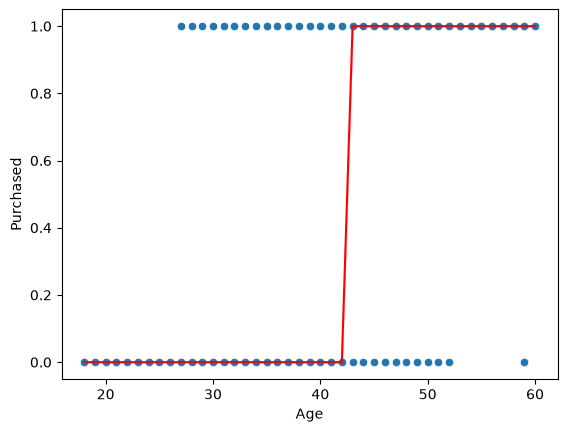

In [7]:
sns.scatterplot(x="Age",y="Purchased" , data= dataset)
sns.lineplot(x="Age" , y=lr.predict(x),data=dataset , color= "red")
plt.show()

In [8]:
from imblearn.under_sampling import RandomUnderSampler

In [10]:
ru = RandomUnderSampler()
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]
ru_x , ru_y = ru.fit_resample(x,y)
ru_x , ru_y.value_counts()

(     Age  EstimatedSalary
 306   51           134000
 177   25            22000
 189   28            32000
 154   40            47000
 348   39            77000
 ..   ...              ...
 393   60            42000
 395   46            41000
 396   51            23000
 397   50            20000
 399   49            36000
 
 [286 rows x 2 columns],
 Purchased
 0    143
 1    143
 Name: count, dtype: int64)

In [11]:
from sklearn.model_selection import train_test_split
x_train1 , x_test1 , y_train1 , y_test1 = train_test_split(ru_x , ru_y , test_size=0.2 , random_state=42)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train1 , y_train1)
lr.score(x_test1,y_test1)*100

82.75862068965517

In [15]:
from imblearn.over_sampling import RandomOverSampler
ro = RandomOverSampler()
ro_x , ro_y = ro.fit_resample(x,y)
ro_y.value_counts()

Purchased
0    257
1    257
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
x_train2 , x_test2 , y_train2 , y_test2 = train_test_split(ro_x , ro_y , test_size=0.2 , random_state=42)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train2 , y_train2)
lr.score(x_test2,y_test2)*100

88.3495145631068